In [1]:
#importing required libraries
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
#read the data set of backorder
backorder_data = pd.read_csv('Back_order_train.csv')

In [3]:
#Display first 5 rows of backorder data set
backorder_data.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


In [4]:
#Information about data type of columns
backorder_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687861 entries, 0 to 1687860
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687861 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  object 
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 non-n

In [5]:
#Shape of backorder data set 
backorder_data.shape

(1687861, 23)

In [6]:
#Describes the backorder data set 
backorder_data.describe()

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,min_bank,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty
count,1.687860e+06,1.586967e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06,1.687860e+06
mean,4.961118e+02,7.872267e+00,4.405202e+01,1.781193e+02,3.449867e+02,5.063644e+02,5.592607e+01,1.750259e+02,3.417288e+02,5.252697e+02,5.277230e+01,2.043724e+00,-6.872059e+00,-6.437947e+00,6.264507e-01
std,2.961523e+04,7.056024e+00,1.342742e+03,5.026553e+03,9.795152e+03,1.437892e+04,1.928196e+03,5.192378e+03,9.613167e+03,1.483861e+04,1.254983e+03,2.360165e+02,2.655636e+01,2.584333e+01,3.372224e+01
min,-2.725600e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.900000e+01,-9.900000e+01,0.000000e+00
25%,4.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.300000e-01,6.600000e-01,0.000000e+00
50%,1.500000e+01,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,8.200000e-01,8.100000e-01,0.000000e+00
75%,8.000000e+01,9.000000e+00,0.000000e+00,4.000000e+00,1.200000e+01,2.000000e+01,4.000000e+00,1.500000e+01,3.100000e+01,4.700000e+01,3.000000e+00,0.000000e+00,9.700000e-01,9.500000e-01,0.000000e+00
max,1.233440e+07,5.200000e+01,4.894080e+05,1.427612e+06,2.461360e+06,3.777304e+06,7.417740e+05,1.105478e+06,2.146625e+06,3.205172e+06,3.133190e+05,1.464960e+05,1.000000e+00,1.000000e+00,1.253000e+04


In [7]:
# Displaying backorder data 
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,No,No,No,Yes,No,No
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,Yes,No,No,No,No,Yes
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,No,No,No,Yes,No,No
1687859,1502009,19.0,4.0,0.0,0.0,0.0,0.0,2.0,7.0,12.0,...,0.0,0.73,0.78,1.0,No,No,No,Yes,No,No


In [8]:
#To remove last row that has all the null values 
backorder_data = backorder_data.dropna(thresh = 2 ,how = 'all')

In [9]:
#Checking whether the data set of back order has null values
backorder_data.isnull().sum()

sku                       0
national_inv              0
lead_time            100893
in_transit_qty            0
forecast_3_month          0
forecast_6_month          0
forecast_9_month          0
sales_1_month             0
sales_3_month             0
sales_6_month             0
sales_9_month             0
min_bank                  0
potential_issue           0
pieces_past_due           0
perf_6_month_avg          0
perf_12_month_avg         0
local_bo_qty              0
deck_risk                 0
oe_constraint             0
ppap_risk                 0
stop_auto_buy             0
rev_stop                  0
went_on_backorder         0
dtype: int64

In [10]:
#Replacing yes/no with 1/0 for potential_issue,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
object_cols = ['potential_issue','deck_risk','oe_constraint','ppap_risk','stop_auto_buy','rev_stop', 'went_on_backorder']

for col in object_cols:
    backorder_data[col]=backorder_data[col].map(dict(Yes=1, No=0))

backorder_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1687860 entries, 0 to 1687859
Data columns (total 23 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   sku                1687860 non-null  object 
 1   national_inv       1687860 non-null  float64
 2   lead_time          1586967 non-null  float64
 3   in_transit_qty     1687860 non-null  float64
 4   forecast_3_month   1687860 non-null  float64
 5   forecast_6_month   1687860 non-null  float64
 6   forecast_9_month   1687860 non-null  float64
 7   sales_1_month      1687860 non-null  float64
 8   sales_3_month      1687860 non-null  float64
 9   sales_6_month      1687860 non-null  float64
 10  sales_9_month      1687860 non-null  float64
 11  min_bank           1687860 non-null  float64
 12  potential_issue    1687860 non-null  int64  
 13  pieces_past_due    1687860 non-null  float64
 14  perf_6_month_avg   1687860 non-null  float64
 15  perf_12_month_avg  1687860 non-n

In [11]:
#Checking for update of values in potential_issue,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,NaN,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,-99.00,-99.00,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [12]:
#Replacing -99 values with nan in perf_6_month_avg,perf_12_month_avg
backorder_data['perf_6_month_avg']=backorder_data['perf_6_month_avg'].replace(-99,np.NaN)
backorder_data['perf_12_month_avg']=backorder_data['perf_12_month_avg'].replace(-99,np.NaN)

In [13]:
#Checking null values in dataset
backorder_data.isnull().sum()

sku                       0
national_inv              0
lead_time            100893
in_transit_qty            0
forecast_3_month          0
forecast_6_month          0
forecast_9_month          0
sales_1_month             0
sales_3_month             0
sales_6_month             0
sales_9_month             0
min_bank                  0
potential_issue           0
pieces_past_due           0
perf_6_month_avg     129478
perf_12_month_avg    122050
local_bo_qty              0
deck_risk                 0
oe_constraint             0
ppap_risk                 0
stop_auto_buy             0
rev_stop                  0
went_on_backorder         0
dtype: int64

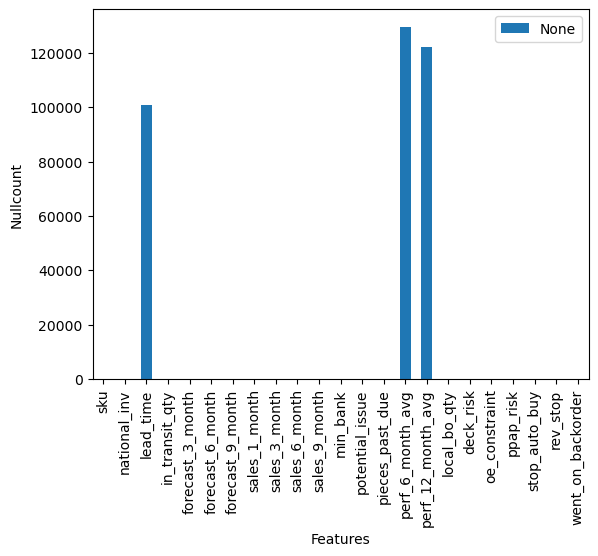

In [14]:
#plotting null values of each feature
null = backorder_data.isnull().sum()
null.plot(kind='bar',xlabel="Features",ylabel="Nullcount")
plt.legend(bbox_to_anchor=(1.0, 1.0))
plt.show()

In [15]:
#Replacing missing values -- Nan values with median of column
for feature in backorder_data.columns:
    backorder_data[feature].fillna(value=backorder_data[feature].median(),inplace=True)
    #backorder_data[feature].replace(NaN,backorder_data[feature].median(),inplace=True)

In [16]:
#checking whether nan values are replaced
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,8.0,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,0.85,0.83,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [17]:
#Checking again for null values 
backorder_data.isnull().sum()

sku                  0
national_inv         0
lead_time            0
in_transit_qty       0
forecast_3_month     0
forecast_6_month     0
forecast_9_month     0
sales_1_month        0
sales_3_month        0
sales_6_month        0
sales_9_month        0
min_bank             0
potential_issue      0
pieces_past_due      0
perf_6_month_avg     0
perf_12_month_avg    0
local_bo_qty         0
deck_risk            0
oe_constraint        0
ppap_risk            0
stop_auto_buy        0
rev_stop             0
went_on_backorder    0
dtype: int64

In [18]:
#To drop duplicates from datasets 
backorder_data= backorder_data.drop_duplicates()
backorder_data

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,0,0,0,1,0,0
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,0,0,0,1,0,0
2,1043696,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,0,0,0,1,0,0
4,1044048,8.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.85,0.83,0.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687855,1407754,0.0,2.0,0.0,10.0,10.0,10.0,0.0,5.0,7.0,...,0.0,0.69,0.69,5.0,1,0,0,1,0,0
1687856,1373987,-1.0,8.0,0.0,5.0,7.0,9.0,1.0,3.0,3.0,...,0.0,0.85,0.83,1.0,0,0,0,1,0,0
1687857,1524346,-1.0,9.0,0.0,7.0,9.0,11.0,0.0,8.0,11.0,...,0.0,0.86,0.84,1.0,1,0,0,0,0,1
1687858,1439563,62.0,9.0,16.0,39.0,87.0,126.0,35.0,63.0,153.0,...,0.0,0.86,0.84,6.0,0,0,0,1,0,0


In [19]:
#Dropping sku column from dataset because it is just a ID 
backorder_data = backorder_data.drop(['sku'],axis=1)

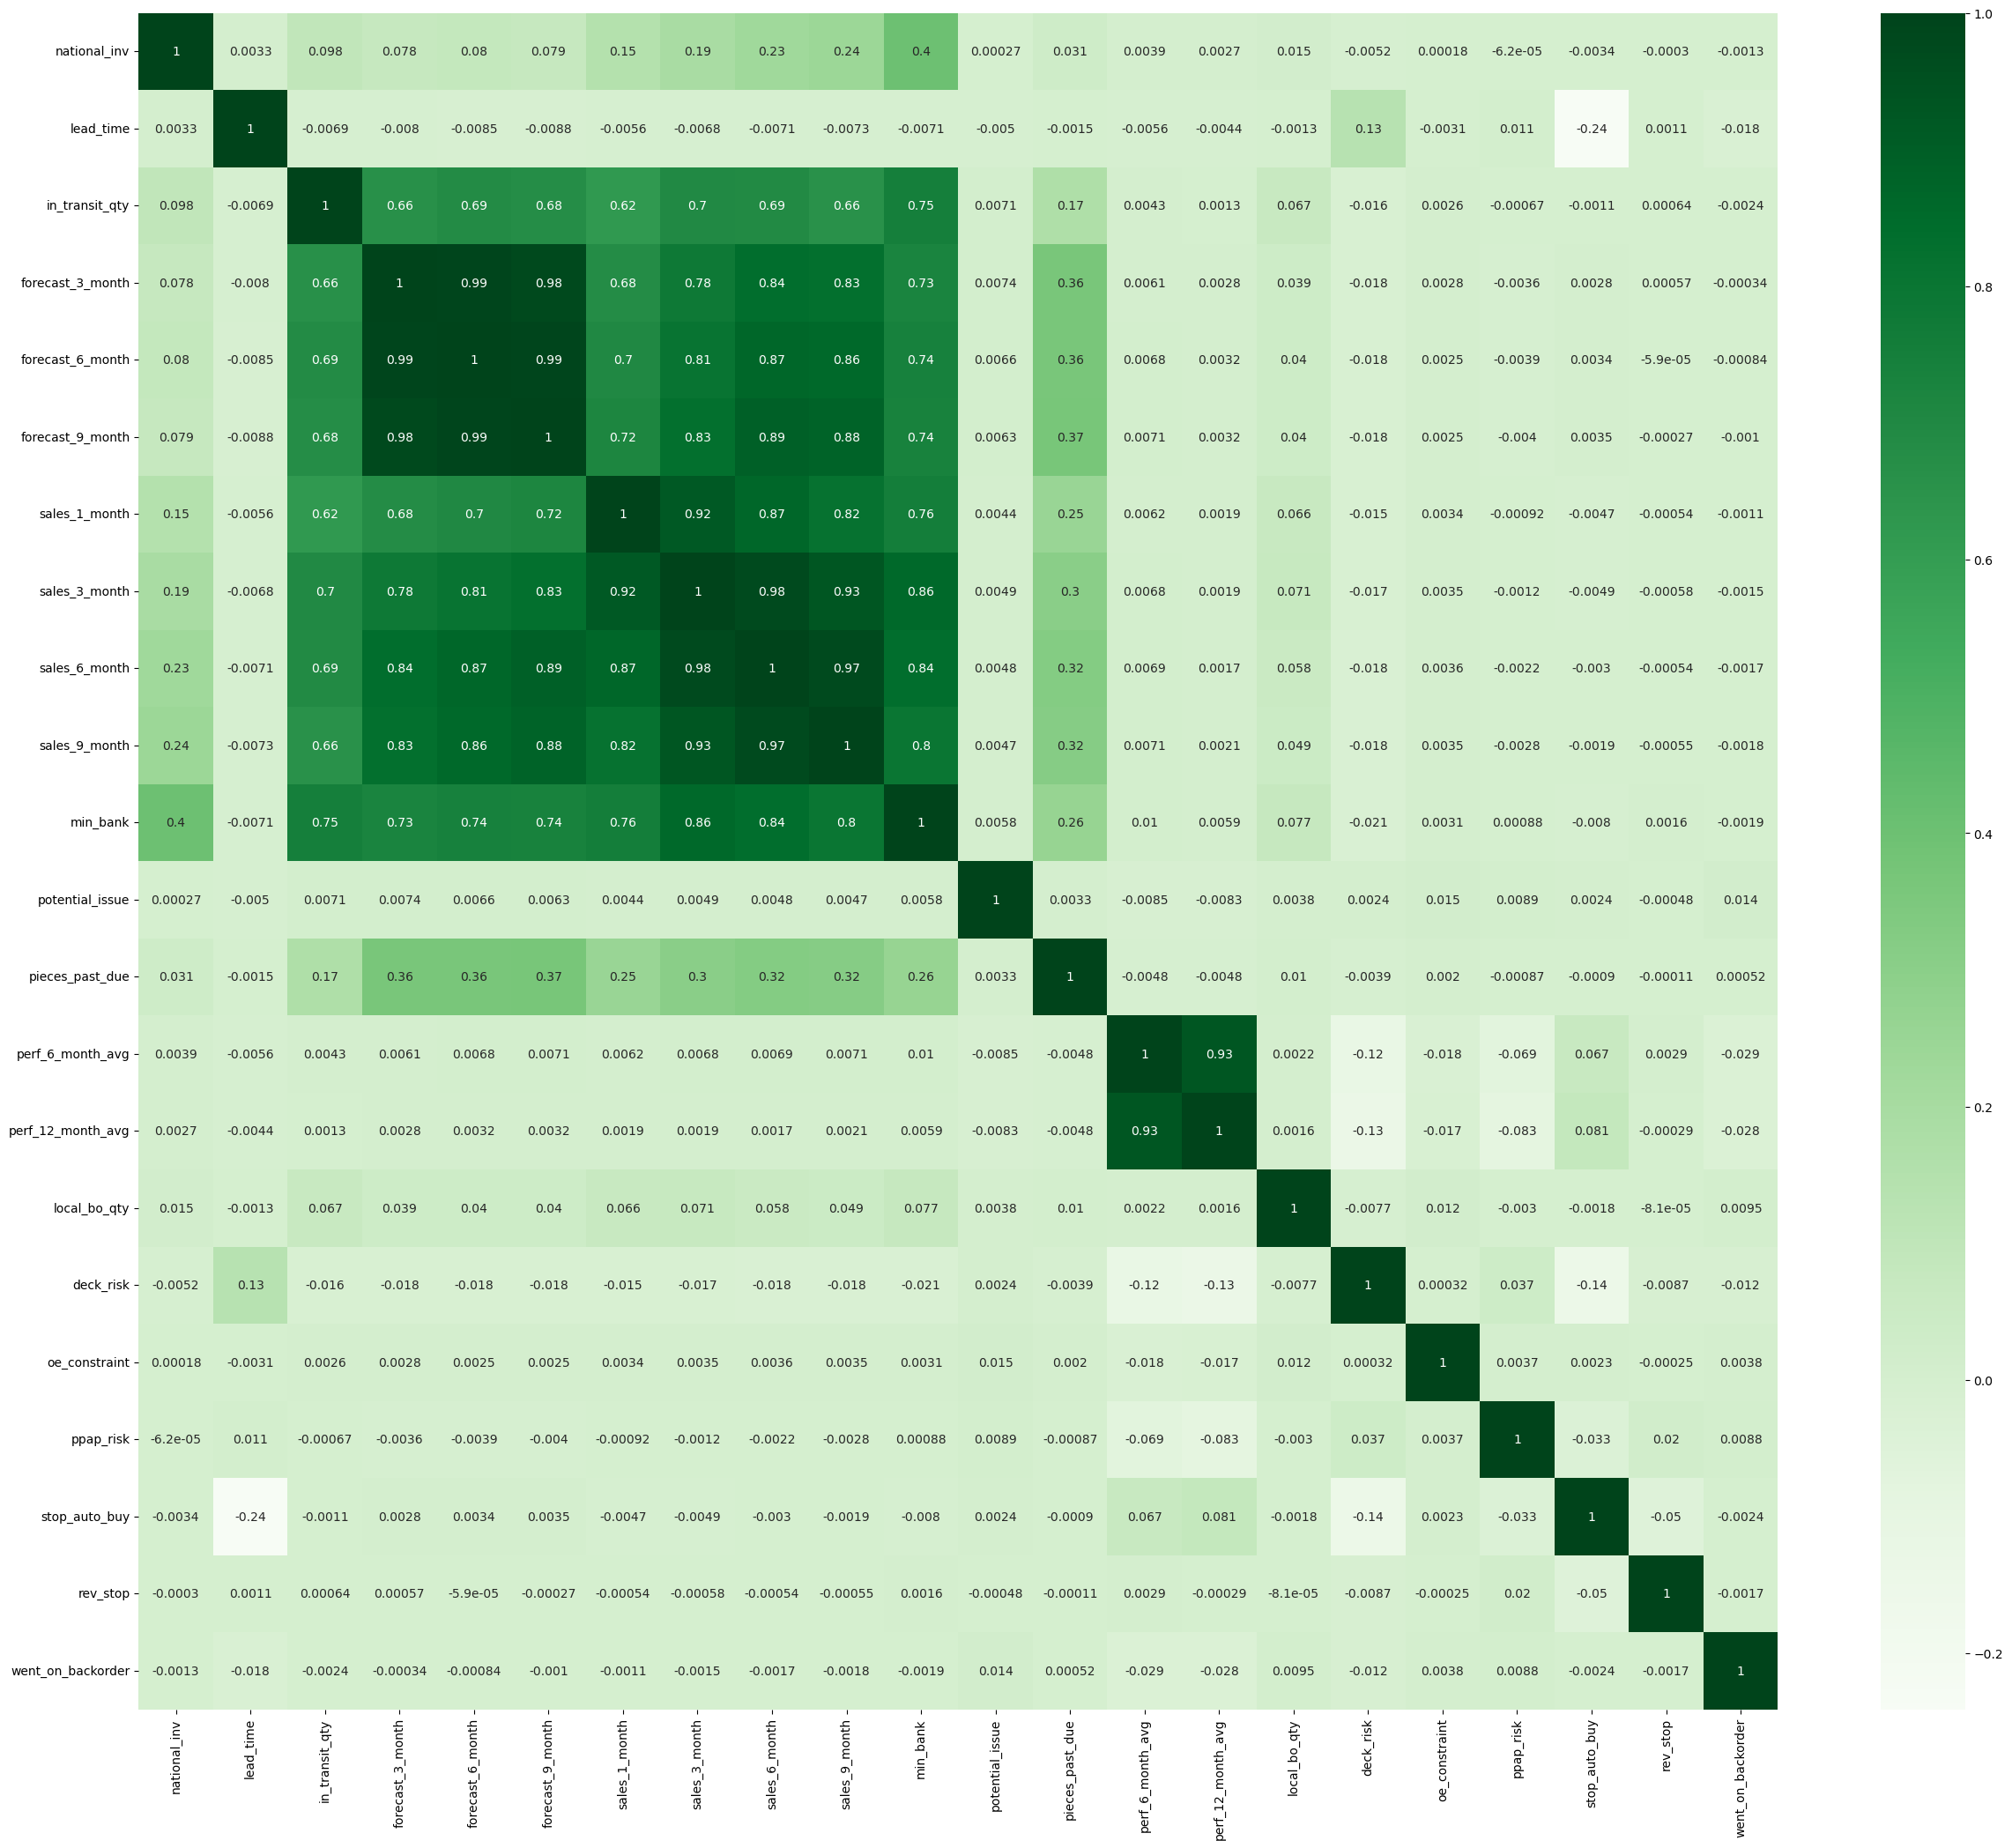

In [20]:
#Plotting correlation between features
backorder_correlation = backorder_data.corr()
plt.figure(figsize=(30,25))
sns.heatmap(backorder_correlation, cmap="Greens",annot=True)
plt.show()

In [21]:
#Correlation between features of dataset
backorder_correlation

,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,sales_9_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
national_inv,1.000000,0.003321,0.098238,0.078199,0.079744,0.078948,0.147449,0.192605,0.225067,0.239613,...,0.030677,0.003929,0.002697,0.014887,-0.005156,0.000185,-0.000062,-0.003380,-0.000305,-0.001315
lead_time,0.003321,1.000000,-0.006863,-0.008045,-0.008548,-0.008773,-0.005618,-0.006769,-0.007117,-0.007261,...,-0.001510,-0.005622,-0.004414,-0.001259,0.134983,-0.003095,0.010739,-0.240950,0.001077,-0.018104
in_transit_qty,0.098238,-0.006863,1.000000,0.662648,0.687768,0.679152,0.619270,0.698417,0.689908,0.659372,...,0.167460,0.004300,0.001344,0.066612,-0.016188,0.002565,-0.000671,-0.001085,0.000644,-0.002427
forecast_3_month,0.078199,-0.008045,0.662648,1.000000,0.990490,0.977337,0.684494,0.781178,0.835585,0.825539,...,0.361214,0.006057,0.002815,0.039419,-0.017508,0.002798,-0.003625,0.002836,0.000574,-0.000340
forecast_6_month,0.079744,-0.008548,0.687768,0.990490,1.000000,0.994945,0.701770,0.808755,0.868099,0.858253,...,0.363147,0.006827,0.003187,0.039724,-0.017789,0.002473,-0.003864,0.003413,-0.000059,-0.000840
forecast_9_month,0.078948,-0.008773,0.679152,0.977337,0.994945,1.000000,0.716367,0.829911,0.891884,0.881894,...,0.366001,0.007113,0.003243,0.039732,-0.017939,0.002493,-0.003956,0.003536,-0.000274,-0.001030
sales_1_month,0.147449,-0.005618,0.619270,0.684494,0.701770,0.716367,1.000000,0.918548,0.867479,0.815959,...,0.249526,0.006216,0.001909,0.066188,-0.014748,0.003402,-0.000919,-0.004737,-0.000541,-0.001131
sales_3_month,0.192605,-0.006769,0.698417,0.781178,0.808755,0.829911,0.918548,1.000000,0.975594,0.929491,...,0.304565,0.006804,0.001913,0.071030,-0.017196,0.003500,-0.001229,-0.004920,-0.000576,-0.001512
sales_6_month,0.225067,-0.007117,0.689908,0.835585,0.868099,0.891884,0.867479,0.975594,1.000000,0.971833,...,0.323552,0.006859,0.001683,0.057765,-0.018170,0.003624,-0.002208,-0.002972,-0.000541,-0.001728
sales_9_month,0.239613,-0.007261,0.659372,0.825539,0.858253,0.881894,0.815959,0.929491,0.971833,1.000000,...,0.317692,0.007138,0.002067,0.048880,-0.018165,0.003477,-0.002783,-0.001894,-0.000547,-0.001764


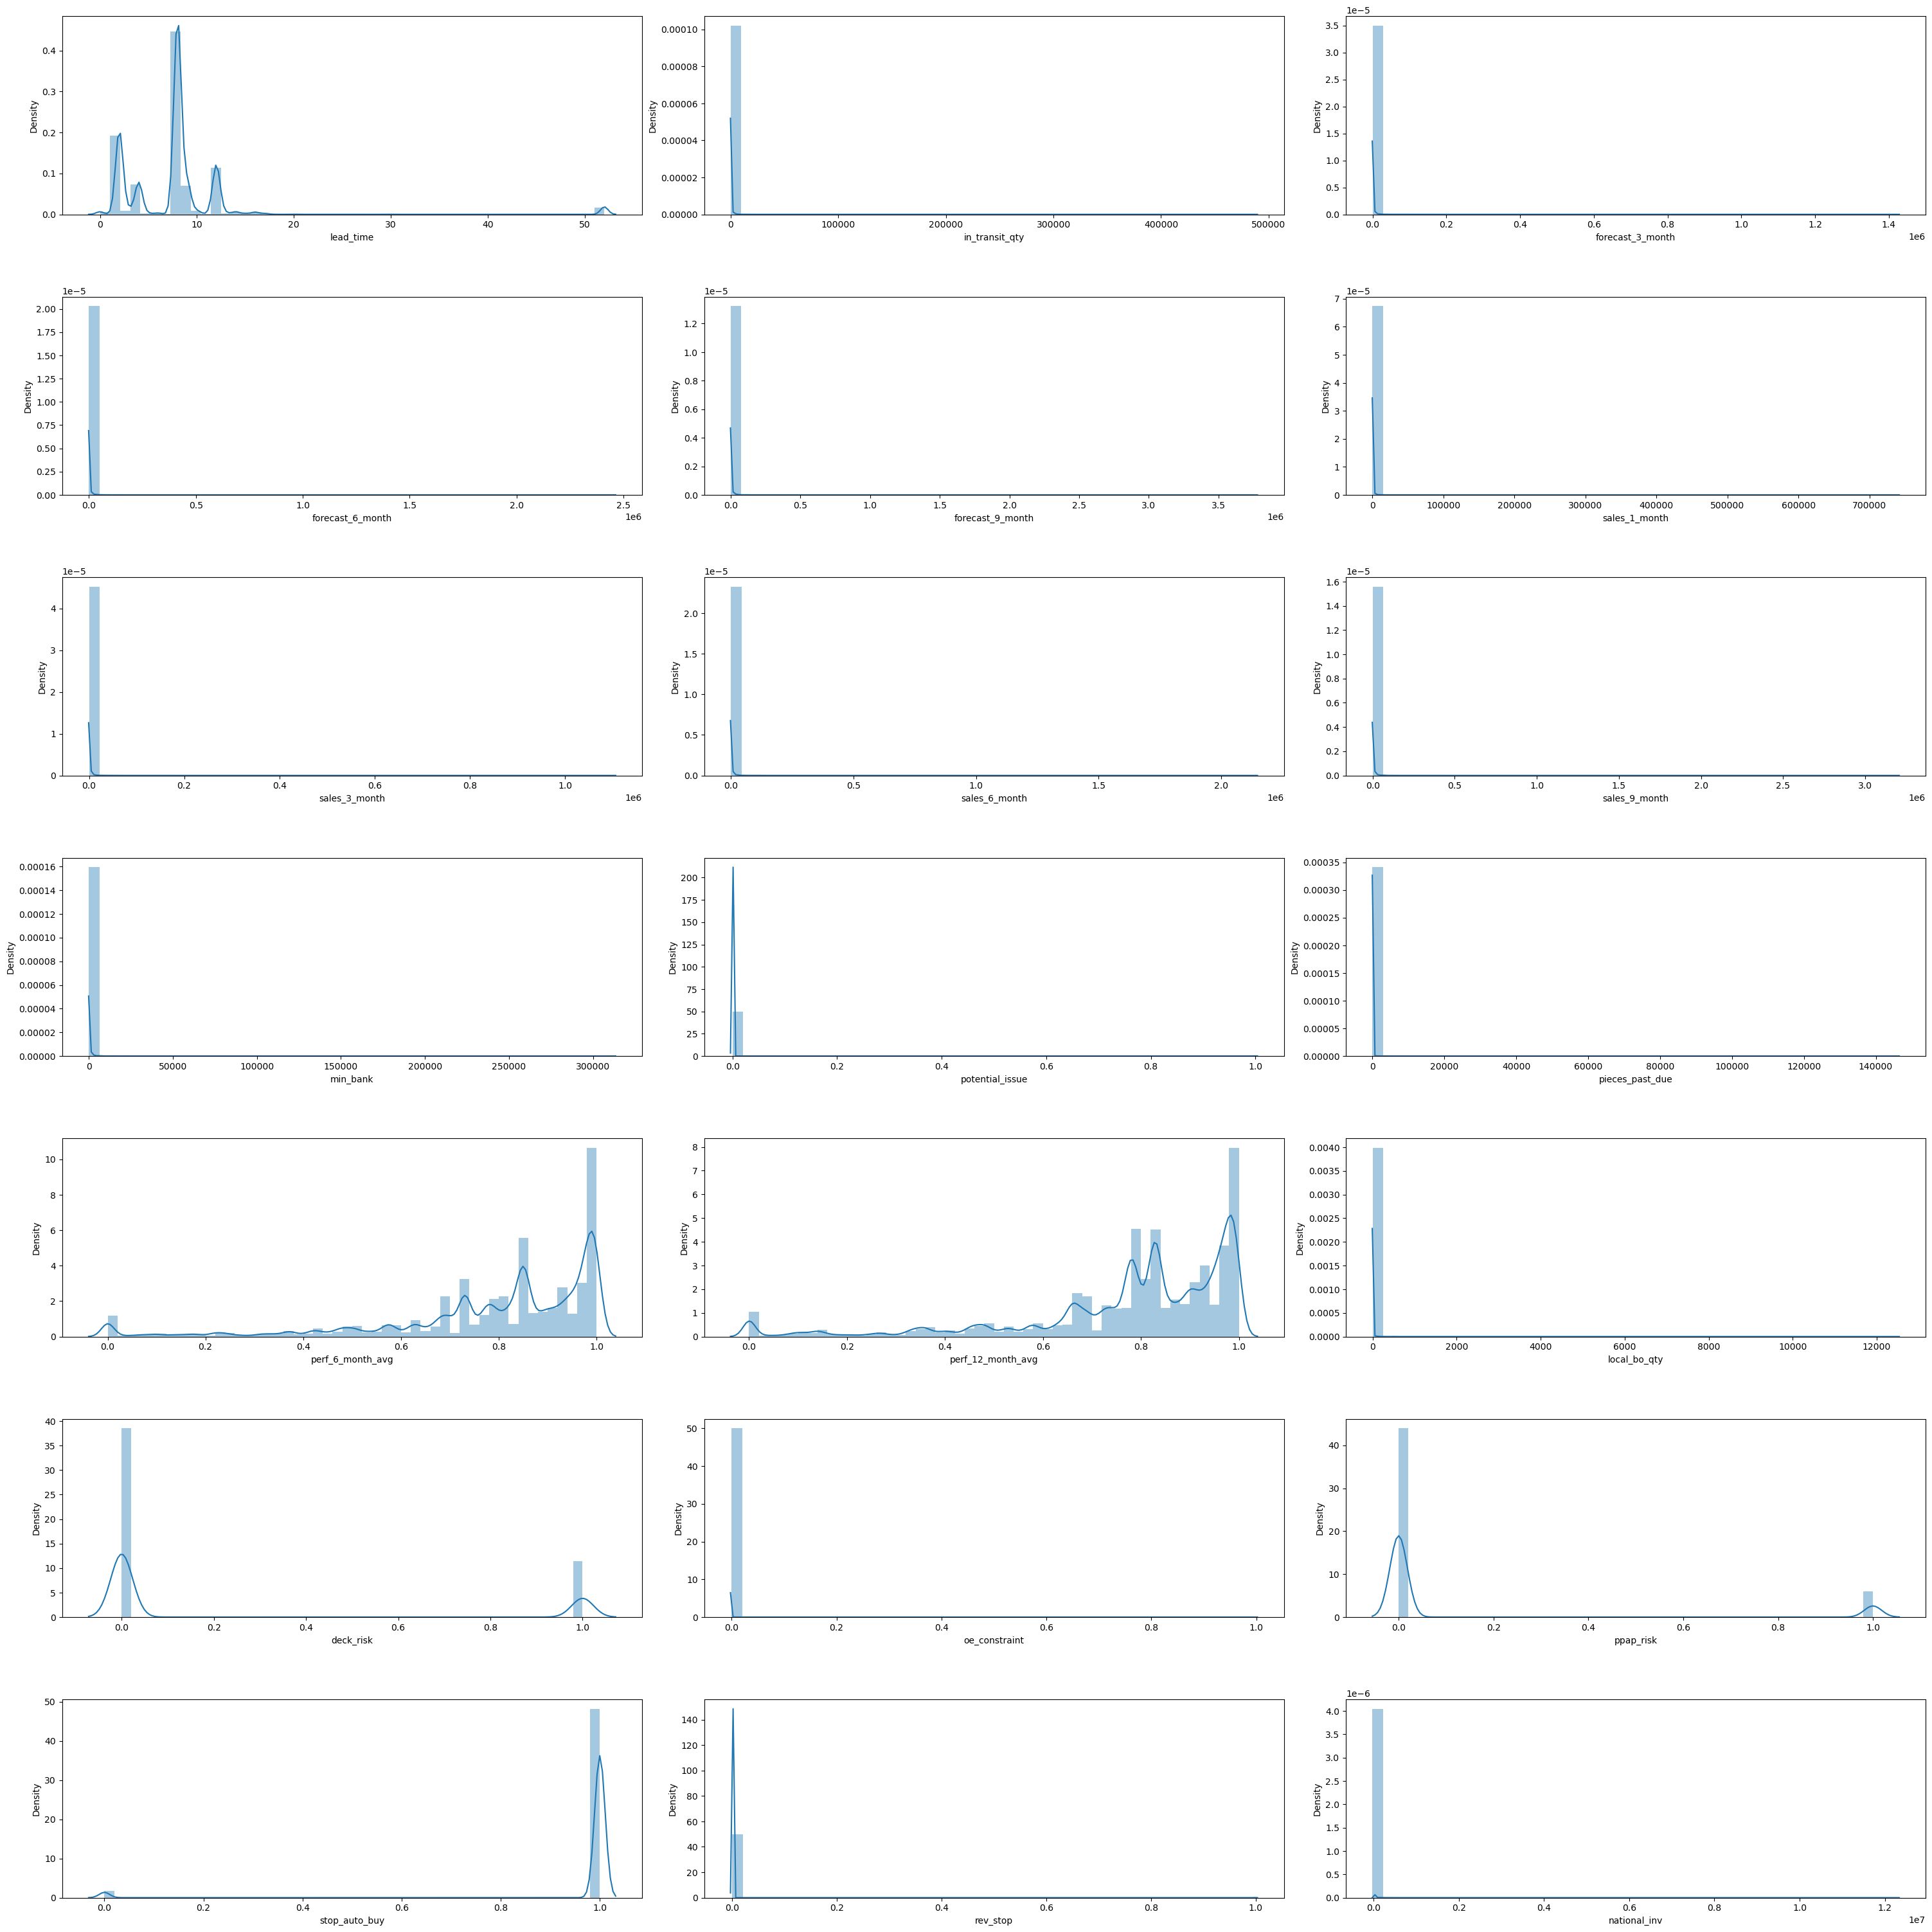

In [22]:
# Density plot of features
figure, ax = plt.subplots(7,3,figsize=(30,30))
index = -1
ax = ax.flatten()
data = backorder_data.drop(['went_on_backorder'],axis=1)
for feature in data.columns:
    sns.distplot(data[feature],ax=ax[index])
    index = index + 1
plt.tight_layout(pad=0.5, w_pad=0.7, h_pad=5.0)

In [23]:
#Target and features seperation
y_target=backorder_data['went_on_backorder']
X_features=backorder_data.drop(['went_on_backorder'], axis=1)

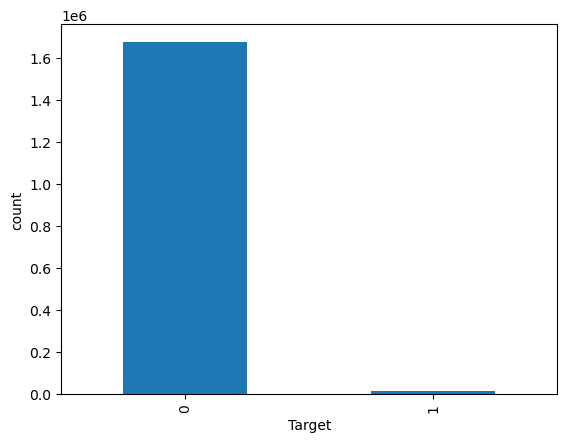

In [24]:
#Plotting count of  different classes in dataset
y_target.value_counts().plot(kind='bar',xlabel="Target",ylabel="count")
plt.show()

In [25]:
# Scores of feature using f_classif feature selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
bestfeatures = SelectKBest(score_func=f_classif, k='all')
fit = bestfeatures.fit(X_features,y_target)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(X_features.columns)
#concat two dataframes for better visualization 
featureScores = pd.concat([dfcolumns,dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #naming the dataframe columns
print(featureScores.nlargest(23,'Score')) 

                Specs        Score
13   perf_6_month_avg  1384.211759
14  perf_12_month_avg  1340.797144
1           lead_time   553.372900
11    potential_issue   335.163422
16          deck_risk   230.729764
15       local_bo_qty   152.461354
18          ppap_risk   131.140228
17      oe_constraint    24.852226
2      in_transit_qty     9.945266
19      stop_auto_buy     9.916481
10           min_bank     5.884902
9       sales_9_month     5.250814
8       sales_6_month     5.042676
20           rev_stop     4.926003
7       sales_3_month     3.860038
0        national_inv     2.920755
6       sales_1_month     2.157402
5    forecast_9_month     1.790051
4    forecast_6_month     1.192261
12    pieces_past_due     0.449553
3    forecast_3_month     0.194768


In [26]:
#Feature selection using f_classif
bestfeatures = SelectKBest(score_func=f_classif, k= 12)
fit = bestfeatures.fit(X_features,y_target)
fit.get_feature_names_out()

array(['lead_time', 'in_transit_qty', 'sales_9_month', 'min_bank',
       'potential_issue', 'perf_6_month_avg', 'perf_12_month_avg',
       'local_bo_qty', 'deck_risk', 'oe_constraint', 'ppap_risk',
       'stop_auto_buy'], dtype=object)

In [27]:
# List of reduced features
X_features_red = backorder_data [['lead_time', 'in_transit_qty', 'min_bank', 'potential_issue',
       'perf_6_month_avg', 'perf_12_month_avg', 'local_bo_qty',
       'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy',
       'rev_stop']]

In [28]:
#Appling scaling on features
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
scaled_feature=scaler.fit_transform(X_features_red)
X_scaled=scaled_feature

In [29]:
#Balancing imbalanced class data using SMOTE
#!pip install imblearn
from imblearn.over_sampling import SMOTE
x_res,y_res = SMOTE().fit_resample(X_scaled,y_target)
y_res.value_counts()

0    1676567
1    1676567
Name: went_on_backorder, dtype: int64

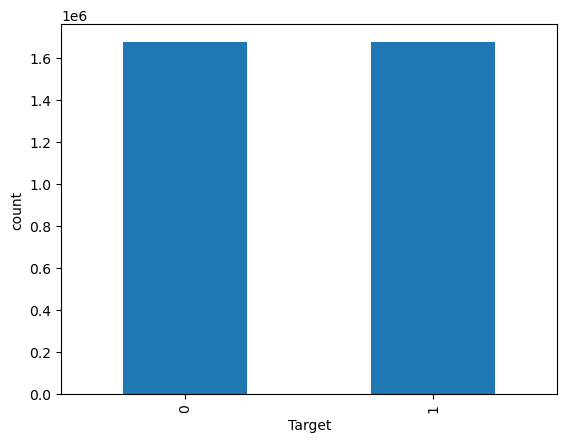

In [30]:
# plotting the different class values after applying smote
y_res.value_counts().plot(kind='bar',xlabel="Target",ylabel="count")
plt.show()

In [31]:
#Spliting data into training and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_res,y_res,test_size=0.2,random_state=100)

In [32]:
# Algorithm Implementation and evaluation metrics with SMOTE 

In [33]:
# importing algorithms and metrics from sklearn
from sklearn import linear_model 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_score,f1_score,recall_score

In [34]:
#Implementation of Logistic Regression
lr_clf = linear_model.LogisticRegression(penalty='l2', C=1.0)
lr_clf.fit(X_train, y_train)
y_predict_lr = lr_clf.predict(X_test)
print("Training Accuracy of Logistic Regression:\n",lr_clf.score(X_train, y_train)*100)
print("Test Accuracy of Logistic Regression:\n",lr_clf.score(X_test,y_test)*100)
print('Confusion Matrix for Logistic Regression:\n ',confusion_matrix(y_test,y_predict_lr))
print('Classification Report for Logistic Regression:\n ',classification_report(y_test,y_predict_lr))
score = roc_auc_score(y_test,lr_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Logistic Regression:\n',score*100)
pr_score = precision_score(y_test,y_predict_lr,average='macro')
score_f1 = f1_score(y_test,y_predict_lr,average='macro')
score_recall = recall_score(y_test,y_predict_lr,average='macro')
print('Percision Score of Logistic Regression:\n',pr_score*100,'\nrecall:',score_recall*100,'\nf1-score:',score_f1*100 )

Training Accuracy of Logistic Regression:
 60.941872658673404
Test Accuracy of Logistic Regression:
 60.9933688920965
Confusion Matrix for Logistic Regression:
  [[216364 119618]
 [141971 192674]]
Classification Report for Logistic Regression:
                precision    recall  f1-score   support

           0       0.60      0.64      0.62    335982
           1       0.62      0.58      0.60    334645

    accuracy                           0.61    670627
   macro avg       0.61      0.61      0.61    670627
weighted avg       0.61      0.61      0.61    670627

ROC_AUC Score of Logistic Regression:
 66.27963882875568
Percision Score of Logistic Regression:
 61.03855783878319 
recall: 60.986568671073194 
f1-score: 60.944633016233205


<AxesSubplot:>

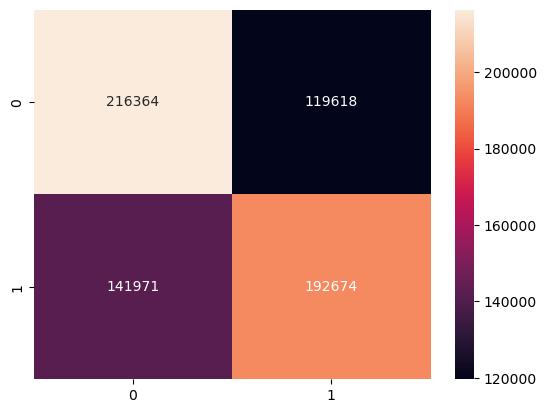

In [35]:
#Heat map for confusion matrix
confusion_matrix_lr = confusion_matrix(y_test,y_predict_lr)
sns.heatmap(confusion_matrix_lr,annot=True,fmt='g')

In [36]:
#Implementation of Decision Tree
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
y_predict_dt = dt_clf.predict(X_test)
print("Training Accuracy of Decision Tree :\n",dt_clf.score(X_train, y_train)*100)
print("Test Accuracy of Decision Tree :\n",dt_clf.score(X_test, y_test)*100)
print('Confusion Matrix for Decision Tree:\n ',confusion_matrix(y_test,y_predict_dt))
print('Classification Report for Decision Tree:\n ',classification_report(y_test,y_predict_dt))
score = roc_auc_score(y_test,dt_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Decision Tree:\n',score*100)
pr_score = precision_score(y_test,y_predict_dt,average='macro')
score_f1 = f1_score(y_test,y_predict_dt,average='macro')
score_recall = recall_score(y_test,y_predict_dt,average='macro')
print('Percision Score of Decision Tree:\n',pr_score*100,'\nrecall:',score_recall*100,'\nf1-score:',score_f1*100 )

Training Accuracy of Decision Tree :
 88.12532455646901
Test Accuracy of Decision Tree :
 87.75772523325188
Confusion Matrix for Decision Tree:
  [[291627  44355]
 [ 37745 296900]]
Classification Report for Decision Tree:
                precision    recall  f1-score   support

           0       0.89      0.87      0.88    335982
           1       0.87      0.89      0.88    334645

    accuracy                           0.88    670627
   macro avg       0.88      0.88      0.88    670627
weighted avg       0.88      0.88      0.88    670627

ROC_AUC Score of Decision Tree:
 96.05458249639162
Percision Score of Decision Tree:
 87.77135066202307 
recall: 87.75964161920035 
f1-score: 87.75696832638253


<AxesSubplot:>

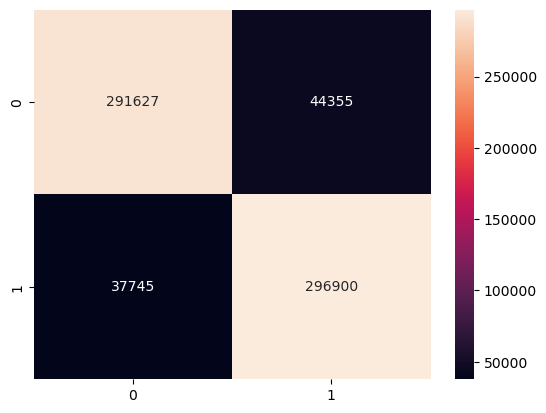

In [37]:
#Heat map for confusion matrix
confusion_matrix_dt = confusion_matrix(y_test,y_predict_dt)
sns.heatmap(confusion_matrix_dt,annot=True,fmt='g')

In [38]:
# Implementation of Random Forest
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
y_predict_rf = rf_clf.predict(X_test)
print("Training Accuracy of Random Forest:\n",rf_clf.score(X_train, y_train)*100)
print("Test Accuracy of Random Forest:\n",rf_clf.score(X_test, y_test)*100)
print('Confusion Matrix for Random Forest:\n ',confusion_matrix(y_test,y_predict_rf))
print('Classification Report for Random Forest:\n ',classification_report(y_test,y_predict_rf))
score = roc_auc_score(y_test,rf_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Random Forest:\n',score*100)
#from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_rf,average='macro')
score_f1 = f1_score(y_test,y_predict_rf,average='macro')
score_recall = recall_score(y_test,y_predict_rf,average='macro')
print('Percision Score of Random Forest:\n',pr_score*100,'\nrecall:',score_recall*100 ,'\nf1-score:',score_f1*100)

Training Accuracy of Random Forest:
 88.12528727790831
Test Accuracy of Random Forest:
 87.88820014702658
Confusion Matrix for Random Forest:
  [[292068  43914]
 [ 37311 297334]]
Classification Report for Random Forest:
                precision    recall  f1-score   support

           0       0.89      0.87      0.88    335982
           1       0.87      0.89      0.88    334645

    accuracy                           0.88    670627
   macro avg       0.88      0.88      0.88    670627
weighted avg       0.88      0.88      0.88    670627

ROC_AUC Score of Random Forest:
 96.3065907448216
Percision Score of Random Forest:
 87.90183643986609 
recall: 87.89011497058571 
f1-score: 87.88745329406889


<AxesSubplot:>

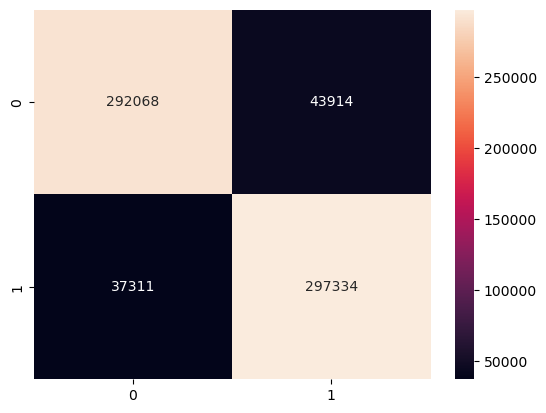

In [39]:
#Heat map for confusion matrix
confusion_matrix_rf = confusion_matrix(y_test,y_predict_rf)
sns.heatmap(confusion_matrix_rf,annot=True,fmt='g')

In [40]:
# Implementation of Gaussian NB
gb_clf = GaussianNB()
gb_clf.fit(X_train, y_train)
y_predict_gb = gb_clf.predict(X_test)
print("Training Accuracy of Gaussian NB:\n",gb_clf.score(X_train, y_train)*100)
print("Test Accuracy of Gaussian NB:\n",gb_clf.score(X_test, y_test)*100)
print('Confusion Matrix for Gaussian NB :\n ',confusion_matrix(y_test,y_predict_gb))
print('Classification Report for Gaussian NB:\n ',classification_report(y_test,y_predict_gb))
score = roc_auc_score(y_test,gb_clf.predict_proba(X_test)[:, 1])
print('ROC_AUC Score of Gaussian NB:\n',score*100)
from sklearn.metrics import precision_score,f1_score,recall_score
pr_score = precision_score(y_test,y_predict_gb,average='macro')
score_f1 = f1_score(y_test,y_predict_gb,average='macro')
score_recall = recall_score(y_test,y_predict_gb,average='macro')
print('Percision Score of Gaussian NB:\n',pr_score*100,'\nrecall:',score_recall*100,'\nf1-score:',score_f1*100, )

Training Accuracy of Gaussian NB:
 52.18353577455716
Test Accuracy of Gaussian NB:
 52.059043253552275
Confusion Matrix for Gaussian NB :
  [[ 18652 317330]
 [  4175 330470]]
Classification Report for Gaussian NB:
                precision    recall  f1-score   support

           0       0.82      0.06      0.10    335982
           1       0.51      0.99      0.67    334645

    accuracy                           0.52    670627
   macro avg       0.66      0.52      0.39    670627
weighted avg       0.66      0.52      0.39    670627

ROC_AUC Score of Gaussian NB:
 62.377369482751355
Percision Score of Gaussian NB:
 66.36222865673945 
recall: 52.151948573425585 
f1-score: 38.83581527485113


<AxesSubplot:>

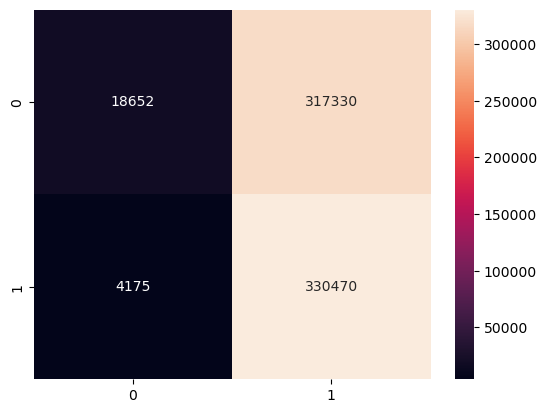

In [41]:
#Heat map for confusion matrix
confusion_matrix_gb = confusion_matrix(y_test,y_predict_gb)
sns.heatmap(confusion_matrix_gb,annot=True,fmt='g')

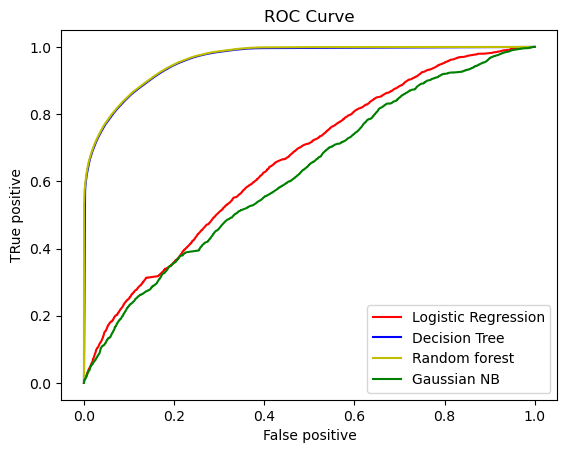

In [42]:
#Plotting ROC curve of classification algorithm 
from sklearn.metrics import roc_curve
fpr_lr,tpr_lr,threshold = roc_curve(y_test,lr_clf.predict_proba(X_test)[:, 1])
fpr_dt,tpr_dt,threshold = roc_curve(y_test,dt_clf.predict_proba(X_test)[:, 1])
fpr_rf,tpr_rf,threshold = roc_curve(y_test,rf_clf.predict_proba(X_test)[:, 1])
fpr_gb,tpr_gb,threshold = roc_curve(y_test,gb_clf.predict_proba(X_test)[:, 1])
plt.title("ROC Curve")
plt.plot(fpr_lr,tpr_lr,'r',label = 'Logistic Regression')
plt.plot(fpr_dt,tpr_dt,'b',label = 'Decision Tree')
plt.plot(fpr_rf,tpr_rf,'y',label = 'Random forest')  
plt.plot(fpr_gb,tpr_gb,'g',label = 'Gaussian NB')
plt.ylabel("TRue positive")
plt.xlabel("False positive")
plt.legend()
plt.show()

In [43]:
# Class Imbalance using ADASYN method and implementing and evaluating performance of classification algorithms 

In [44]:
#Balancing imbalanced class data using ADASYN
#!pip install imblearn
from imblearn.over_sampling import ADASYN
x_res_ada,y_res_ada = ADASYN().fit_resample(X_scaled,y_target)
y_res_ada.value_counts()

0    1676567
1    1674597
Name: went_on_backorder, dtype: int64

In [45]:
#Spliting data into training and test data
from sklearn.model_selection import train_test_split
X_train_ada,X_test_ada,y_train_ada,y_test_ada = train_test_split(x_res_ada,y_res_ada,test_size=0.2,random_state=100)

In [46]:
#Implementation of Logistic Regression
lr_clf_ada = linear_model.LogisticRegression(penalty='l2', C=1.0)
lr_clf_ada.fit(X_train_ada, y_train_ada)
y_predict_lr_ada = lr_clf_ada.predict(X_test_ada)
print("Training Accuracy of Logistic Regression:\n",lr_clf_ada.score(X_train_ada, y_train_ada)*100)
print("Test Accuracy of Logistic Regression:\n",lr_clf_ada.score(X_test_ada,y_test_ada)*100)
print('Confusion Matrix for Logistic Regression:\n ',confusion_matrix(y_test_ada,y_predict_lr_ada))
print('Classification Report for Logistic Regression:\n ',classification_report(y_test_ada,y_predict_lr_ada))
score_ada = roc_auc_score(y_test_ada,lr_clf_ada.predict_proba(X_test_ada)[:, 1])
print('ROC_AUC Score of Logistic Regression:\n',score_ada*100)
pr_score_ada = precision_score(y_test_ada,y_predict_lr_ada,average='macro')
score_f1_ada = f1_score(y_test_ada,y_predict_lr_ada,average='macro')
score_recall_ada = recall_score(y_test_ada,y_predict_lr_ada,average='macro')
print('Percision Score of Logistic Regression:\n',pr_score_ada*100,'\nrecall:',score_recall_ada*100,'\nf1-score:',score_f1_ada*100 )

Training Accuracy of Logistic Regression:
 60.06473124448186
Test Accuracy of Logistic Regression:
 60.065678652050856
Confusion Matrix for Logistic Regression:
  [[213747 121936]
 [145717 188833]]
Classification Report for Logistic Regression:
                precision    recall  f1-score   support

           0       0.59      0.64      0.61    335683
           1       0.61      0.56      0.59    334550

    accuracy                           0.60    670233
   macro avg       0.60      0.60      0.60    670233
weighted avg       0.60      0.60      0.60    670233

ROC_AUC Score of Logistic Regression:
 65.13712824505411
Percision Score of Logistic Regression:
 60.11291960028936 
recall: 60.05956648960049 
f1-score: 60.01042231099524


<AxesSubplot:>

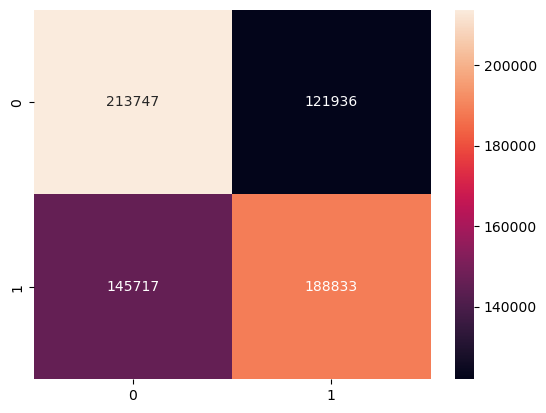

In [47]:
#Heat map for confusion matrix
confusion_matrix_lr_ada = confusion_matrix(y_test_ada,y_predict_lr_ada)
sns.heatmap(confusion_matrix_lr_ada,annot=True,fmt='g')

In [48]:
#Implementation of Decision Tree
dt_clf_ada = DecisionTreeClassifier()
dt_clf_ada.fit(X_train_ada, y_train_ada)
y_predict_dt_ada = dt_clf_ada.predict(X_test_ada)
print("Training Accuracy of Decision Tree :\n",dt_clf_ada.score(X_train_ada, y_train_ada)*100)
print("Test Accuracy of Decision Tree :\n",dt_clf_ada.score(X_test_ada, y_test_ada)*100)
print('Confusion Matrix for Decision Tree:\n ',confusion_matrix(y_test_ada,y_predict_dt_ada))
print('Classification Report for Decision Tree:\n ',classification_report(y_test_ada,y_predict_dt_ada))
score_ada = roc_auc_score(y_test_ada,dt_clf_ada.predict_proba(X_test_ada)[:, 1])
print('ROC_AUC Score of Decision Tree:\n',score_ada*100)
pr_score_ada = precision_score(y_test_ada,y_predict_dt_ada,average='macro')
score_f1_ada = f1_score(y_test_ada,y_predict_dt_ada,average='macro')
score_recall_ada = recall_score(y_test_ada,y_predict_dt_ada,average='macro')
print('Percision Score of Decision Tree:\n',pr_score_ada*100,'\nrecall:',score_recall_ada*100,'\nf1-score:',score_f1_ada*100 )

Training Accuracy of Decision Tree :
 87.57853148775555
Test Accuracy of Decision Tree :
 87.2829299661461
Confusion Matrix for Decision Tree:
  [[283807  51876]
 [ 33358 301192]]
Classification Report for Decision Tree:
                precision    recall  f1-score   support

           0       0.89      0.85      0.87    335683
           1       0.85      0.90      0.88    334550

    accuracy                           0.87    670233
   macro avg       0.87      0.87      0.87    670233
weighted avg       0.87      0.87      0.87    670233

ROC_AUC Score of Decision Tree:
 95.64730322027879
Percision Score of Decision Tree:
 87.39476285073869 
recall: 87.28756423529946 
f1-score: 87.2743679283981


<AxesSubplot:>

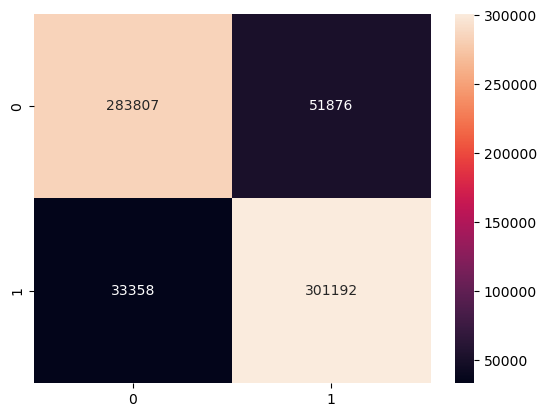

In [49]:
#Heat map for confusion matrix
confusion_matrix_dt_ada = confusion_matrix(y_test_ada,y_predict_dt_ada)
sns.heatmap(confusion_matrix_dt_ada,annot=True,fmt='g')

In [50]:
# Implementation of Random Forest
rf_clf_ada = RandomForestClassifier()
rf_clf_ada.fit(X_train_ada, y_train_ada)
y_predict_rf_ada = rf_clf_ada.predict(X_test_ada)
print("Training Accuracy of Random Forest:\n",rf_clf_ada.score(X_train_ada, y_train_ada)*100)
print("Test Accuracy of Random Forest:\n",rf_clf_ada.score(X_test_ada, y_test_ada)*100)
print('Confusion Matrix for Random Forest:\n ',confusion_matrix(y_test_ada,y_predict_rf_ada))
print('Classification Report for Random Forest:\n ',classification_report(y_test_ada,y_predict_rf_ada))
score_ada = roc_auc_score(y_test_ada,rf_clf_ada.predict_proba(X_test_ada)[:, 1])
print('ROC_AUC Score of Random Forest:\n',score_ada*100)
pr_score_ada = precision_score(y_test_ada,y_predict_rf_ada,average='macro')
score_f1_ada = f1_score(y_test_ada,y_predict_rf_ada,average='macro')
score_recall_ada = recall_score(y_test_ada,y_predict_rf_ada,average='macro')
print('Percision Score of Random Forest:\n',pr_score_ada*100,'\nrecall:',score_recall_ada*100 ,'\nf1-score:',score_f1_ada*100)

Training Accuracy of Random Forest:
 87.57827038442989
Test Accuracy of Random Forest:
 87.41139275446001
Confusion Matrix for Random Forest:
  [[284012  51671]
 [ 32702 301848]]
Classification Report for Random Forest:
                precision    recall  f1-score   support

           0       0.90      0.85      0.87    335683
           1       0.85      0.90      0.88    334550

    accuracy                           0.87    670233
   macro avg       0.88      0.87      0.87    670233
weighted avg       0.88      0.87      0.87    670233

ROC_AUC Score of Random Forest:
 95.90232969246502
Percision Score of Random Forest:
 87.52920423805426 
recall: 87.41614114193938 
f1-score: 87.40247144376542


<AxesSubplot:>

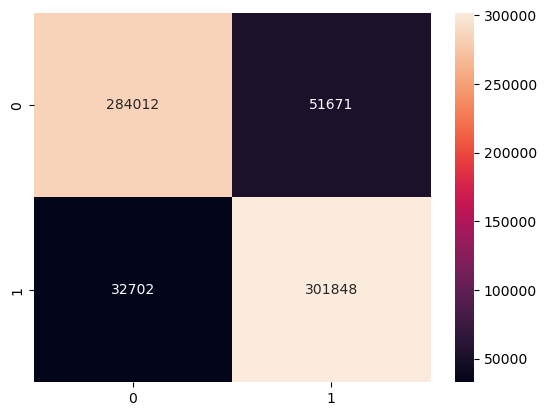

In [51]:
#Heat map for confusion matrix
confusion_matrix_rf_ada = confusion_matrix(y_test_ada,y_predict_rf_ada)
sns.heatmap(confusion_matrix_rf_ada,annot=True,fmt='g')

In [52]:
# Implementation of Gaussian NB
gb_clf_ada = GaussianNB()
gb_clf_ada.fit(X_train_ada, y_train_ada)
y_predict_gb_ada = gb_clf_ada.predict(X_test_ada)
print("Training Accuracy of Gaussian NB:\n",gb_clf_ada.score(X_train_ada, y_train_ada)*100)
print("Test Accuracy of Gaussian NB:\n",gb_clf_ada.score(X_test_ada, y_test_ada)*100)
print('Confusion Matrix for Gaussian NB :\n ',confusion_matrix(y_test_ada,y_predict_gb_ada))
print('Classification Report for Gaussian NB:\n ',classification_report(y_test_ada,y_predict_gb_ada))
score_ada = roc_auc_score(y_test_ada,gb_clf_ada.predict_proba(X_test_ada)[:, 1])
print('ROC_AUC Score of Gaussian NB:\n',score_ada*100)
pr_score_ada = precision_score(y_test_ada,y_predict_gb_ada,average='macro')
score_f1_ada = f1_score(y_test_ada,y_predict_gb_ada,average='macro')
score_recall_ada = recall_score(y_test_ada,y_predict_gb_ada,average='macro')
print('Percision Score of Gaussian NB:\n',pr_score_ada*100,'\nrecall:',score_recall_ada*100,'\nf1-score:',score_f1_ada*100, )

Training Accuracy of Gaussian NB:
 52.061541307851634
Test Accuracy of Gaussian NB:
 51.998782512946995
Confusion Matrix for Gaussian NB :
  [[ 18028 317655]
 [  4065 330485]]
Classification Report for Gaussian NB:
                precision    recall  f1-score   support

           0       0.82      0.05      0.10    335683
           1       0.51      0.99      0.67    334550

    accuracy                           0.52    670233
   macro avg       0.66      0.52      0.39    670233
weighted avg       0.66      0.52      0.39    670233

ROC_AUC Score of Gaussian NB:
 61.1087246034091
Percision Score of Gaussian NB:
 66.29513112384149 
recall: 52.07773901469631 
f1-score: 38.66955351637994


<AxesSubplot:>

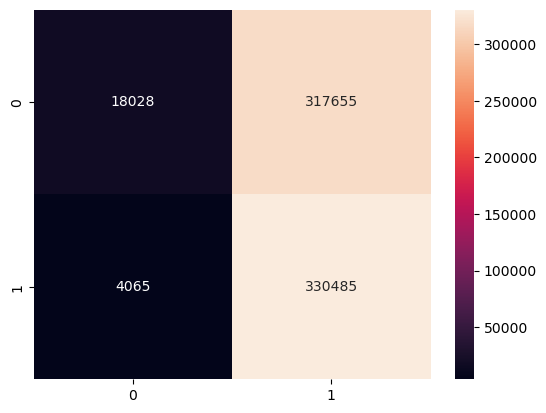

In [53]:
#Heat map for confusion matrix
confusion_matrix_gb_ada = confusion_matrix(y_test_ada,y_predict_gb_ada)
sns.heatmap(confusion_matrix_gb_ada,annot=True,fmt='g')

<function matplotlib.pyplot.show(close=None, block=None)>

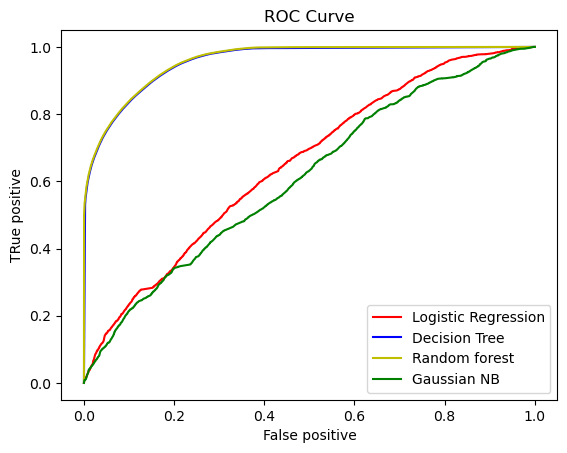

In [54]:
#Plotting ROC curve of classification algorithm 
from sklearn.metrics import roc_curve
fpr_lr_ada,tpr_lr_ada,threshold_ada = roc_curve(y_test_ada,lr_clf_ada.predict_proba(X_test_ada)[:, 1])
fpr_dt_ada,tpr_dt_ada,threshold_ada  = roc_curve(y_test_ada,dt_clf_ada.predict_proba(X_test_ada)[:, 1])
fpr_rf_ada,tpr_rf_ada,threshold_ada  = roc_curve(y_test_ada,rf_clf_ada.predict_proba(X_test_ada)[:, 1])
fpr_gb_ada,tpr_gb_ada,threshold_ada  = roc_curve(y_test_ada,gb_clf_ada.predict_proba(X_test_ada)[:, 1])
plt.title("ROC Curve")
plt.plot(fpr_lr_ada,tpr_lr_ada,'r',label = 'Logistic Regression')
plt.plot(fpr_dt_ada,tpr_dt_ada,'b',label = 'Decision Tree')
plt.plot(fpr_rf_ada,tpr_rf_ada,'y',label = 'Random forest')  
plt.plot(fpr_gb_ada,tpr_gb_ada,'g',label = 'Gaussian NB')
plt.ylabel("TRue positive")
plt.xlabel("False positive")
plt.legend()
plt.show

In [55]:
# Class Imbalance using Random Under Sampling method and implementing, evaluating performance of classification algorithms 

In [56]:
#Balancing imbalanced class data using RandomUnderSampler
#!pip install imblearn
from imblearn.under_sampling import RandomUnderSampler
x_res_rus,y_res_rus = RandomUnderSampler().fit_resample(X_scaled,y_target)
y_res_rus.value_counts()

0    11293
1    11293
Name: went_on_backorder, dtype: int64

<AxesSubplot:xlabel='Target', ylabel='count'>

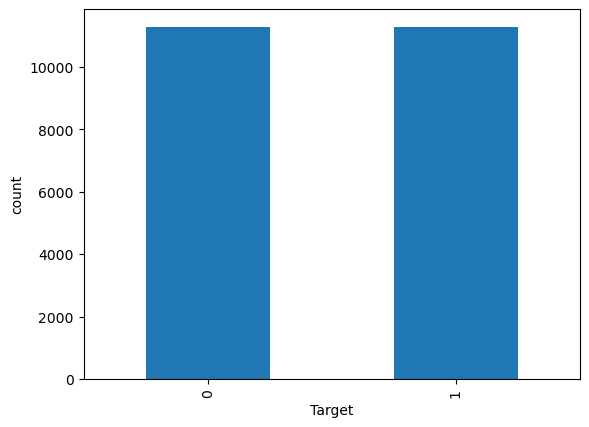

In [57]:
y_res_rus.value_counts().plot(kind='bar',xlabel="Target",ylabel="count")

In [58]:
#Spliting data into training and test data
from sklearn.model_selection import train_test_split
X_train_rus,X_test_rus,y_train_rus,y_test_rus = train_test_split(x_res_rus,y_res_rus,test_size=0.2,random_state=100)

In [59]:
#Implementation of Logistic Regression
lr_clf_rus = linear_model.LogisticRegression(penalty='l2', C=1.0)
lr_clf_rus.fit(X_train_rus, y_train_rus)
y_predict_lr_rus = lr_clf_rus.predict(X_test_rus)
print("Training Accuracy of Logistic Regression:\n",lr_clf_rus.score(X_train_rus, y_train_rus)*100)
print("Test Accuracy of Logistic Regression:\n",lr_clf_rus.score(X_test_rus,y_test_rus)*100)
print('Confusion Matrix for Logistic Regression:\n ',confusion_matrix(y_test_rus,y_predict_lr_rus))
print('Classification Report for Logistic Regression:\n ',classification_report(y_test_rus,y_predict_lr_rus))
score_rus = roc_auc_score(y_test_rus,lr_clf_rus.predict_proba(X_test_rus)[:, 1])
print('ROC_AUC Score of Logistic Regression:\n',score_rus*100)
pr_score_rus = precision_score(y_test_rus,y_predict_lr_rus,average='macro')
score_f1_rus = f1_score(y_test_rus,y_predict_lr_rus,average='macro')
score_recall_rus = recall_score(y_test_rus,y_predict_lr_rus,average='macro')
print('Percision Score of Logistic Regression:\n',pr_score_rus*100,'\nrecall:',score_recall_rus*100,'\nf1-score:',score_f1_rus*100 )

Training Accuracy of Logistic Regression:
 61.22979853885322
Test Accuracy of Logistic Regression:
 61.79725542275343
Confusion Matrix for Logistic Regression:
  [[1502  773]
 [ 953 1290]]
Classification Report for Logistic Regression:
                precision    recall  f1-score   support

           0       0.61      0.66      0.64      2275
           1       0.63      0.58      0.60      2243

    accuracy                           0.62      4518
   macro avg       0.62      0.62      0.62      4518
weighted avg       0.62      0.62      0.62      4518

ROC_AUC Score of Logistic Regression:
 68.34879698990265
Percision Score of Logistic Regression:
 61.855779207509286 
recall: 61.76711919377992 
f1-score: 61.71295473448231


<AxesSubplot:>

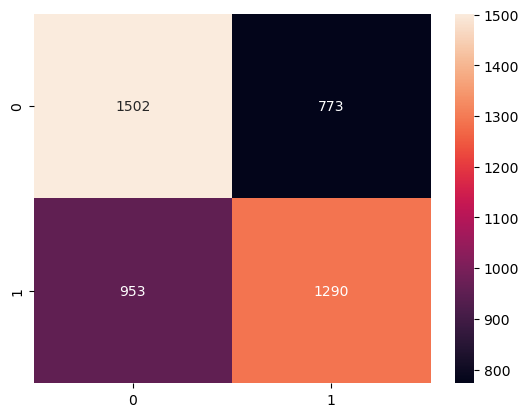

In [60]:
#Heat map for confusion matrix
confusion_matrix_lr_rus = confusion_matrix(y_test_rus,y_predict_lr_rus)
sns.heatmap(confusion_matrix_lr_rus,annot=True,fmt='g')

In [61]:
#Implementation of Decision Tree
dt_clf_rus = DecisionTreeClassifier()
dt_clf_rus.fit(X_train_rus, y_train_rus)
y_predict_dt_rus = dt_clf_rus.predict(X_test_rus)
print("Training Accuracy of Decision Tree :\n",dt_clf_rus.score(X_train_rus, y_train_rus)*100)
print("Test Accuracy of Decision Tree :\n",dt_clf_rus.score(X_test_rus, y_test_rus)*100)
print('Confusion Matrix for Decision Tree:\n ',confusion_matrix(y_test_rus,y_predict_dt_rus))
print('Classification Report for Decision Tree:\n ',classification_report(y_test_rus,y_predict_dt_rus))
score_rus = roc_auc_score(y_test_rus,dt_clf_rus.predict_proba(X_test_rus)[:, 1])
print('ROC_AUC Score of Decision Tree:\n',score_rus*100)
pr_score_rus = precision_score(y_test_rus,y_predict_dt_rus,average='macro')
score_f1_rus = f1_score(y_test_rus,y_predict_dt_rus,average='macro')
score_recall_rus = recall_score(y_test_rus,y_predict_dt_rus,average='macro')
print('Percision Score of Decision Tree:\n',pr_score_rus*100,'\nrecall:',score_recall_rus*100,'\nf1-score:',score_f1_rus*100 )

Training Accuracy of Decision Tree :
 86.52866947088775
Test Accuracy of Decision Tree :
 71.91235059760956
Confusion Matrix for Decision Tree:
  [[1642  633]
 [ 636 1607]]
Classification Report for Decision Tree:
                precision    recall  f1-score   support

           0       0.72      0.72      0.72      2275
           1       0.72      0.72      0.72      2243

    accuracy                           0.72      4518
   macro avg       0.72      0.72      0.72      4518
weighted avg       0.72      0.72      0.72      4518

ROC_AUC Score of Decision Tree:
 76.02128232890604
Percision Score of Decision Tree:
 71.91092201806096 
recall: 71.91047116058262 
f1-score: 71.91066487894648


<AxesSubplot:>

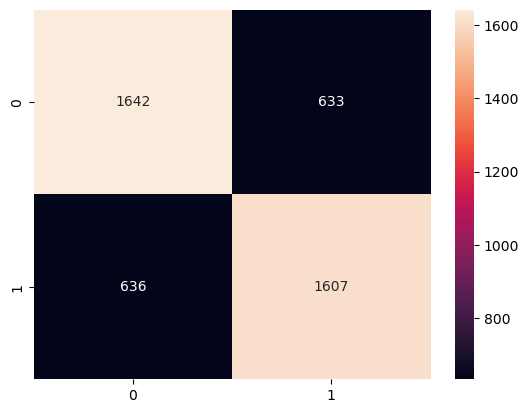

In [62]:
#Heat map for confusion matrix
confusion_matrix_dt_rus = confusion_matrix(y_test_rus,y_predict_dt_rus)
sns.heatmap(confusion_matrix_dt_rus,annot=True,fmt='g')

In [63]:
# Implementation of Random Forest
rf_clf_rus = RandomForestClassifier()
rf_clf_rus.fit(X_train_rus, y_train_rus)
y_predict_rf_rus = rf_clf_rus.predict(X_test_rus)
print("Training Accuracy of Random Forest:\n",rf_clf_rus.score(X_train_rus, y_train_rus)*100)
print("Test Accuracy of Random Forest:\n",rf_clf_rus.score(X_test_rus, y_test_rus)*100)
print('Confusion Matrix for Random Forest:\n ',confusion_matrix(y_test_rus,y_predict_rf_rus))
print('Classification Report for Random Forest:\n ',classification_report(y_test_rus,y_predict_rf_rus))
score_rus = roc_auc_score(y_test_rus,rf_clf_rus.predict_proba(X_test_rus)[:, 1])
print('ROC_AUC Score of Random Forest:\n',score_rus*100)
pr_score_rus = precision_score(y_test_rus,y_predict_rf_rus,average='macro')
score_f1_rus = f1_score(y_test_rus,y_predict_rf_rus,average='macro')
score_recall_rus = recall_score(y_test_rus,y_predict_rf_rus,average='macro')
print('Percision Score of Random Forest:\n',pr_score_rus*100,'\nrecall:',score_recall_rus*100 ,'\nf1-score:',score_f1_rus*100)

Training Accuracy of Random Forest:
 86.52313482399822
Test Accuracy of Random Forest:
 73.86011509517486
Confusion Matrix for Random Forest:
  [[1652  623]
 [ 558 1685]]
Classification Report for Random Forest:
                precision    recall  f1-score   support

           0       0.75      0.73      0.74      2275
           1       0.73      0.75      0.74      2243

    accuracy                           0.74      4518
   macro avg       0.74      0.74      0.74      4518
weighted avg       0.74      0.74      0.74      4518

ROC_AUC Score of Random Forest:
 81.82713496935521
Percision Score of Random Forest:
 73.87903181536579 
recall: 73.86899413560135 
f1-score: 73.85872045469075


<AxesSubplot:>

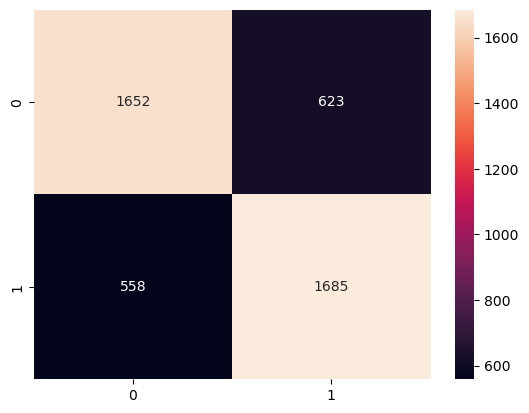

In [64]:
#Heat map for confusion matrix
confusion_matrix_rf_rus = confusion_matrix(y_test_rus,y_predict_rf_rus)
sns.heatmap(confusion_matrix_rf_rus,annot=True,fmt='g')

In [65]:
# Implementation of Gaussian NB
gb_clf_rus = GaussianNB()
gb_clf_rus.fit(X_train_rus, y_train_rus)
y_predict_gb_rus = gb_clf_rus.predict(X_test_rus)
print("Training Accuracy of Gaussian NB:\n",gb_clf_rus.score(X_train_rus, y_train_rus)*100)
print("Test Accuracy of Gaussian NB:\n",gb_clf_rus.score(X_test_rus, y_test_rus)*100)
print('Confusion Matrix for Gaussian NB :\n ',confusion_matrix(y_test_rus,y_predict_gb_rus))
print('Classification Report for Gaussian NB:\n ',classification_report(y_test_rus,y_predict_gb_rus))
score_rus = roc_auc_score(y_test_rus,gb_clf_rus.predict_proba(X_test_rus)[:, 1])
print('ROC_AUC Score of Gaussian NB:\n',score_rus*100)
pr_score_rus = precision_score(y_test_rus,y_predict_gb_rus,average='macro')
score_f1_rus = f1_score(y_test_rus,y_predict_gb_rus,average='macro')
score_recall_rus = recall_score(y_test_rus,y_predict_gb_rus,average='macro')
print('Percision Score of Gaussian NB:\n',pr_score_rus*100,'\nrecall:',score_recall_rus*100,'\nf1-score:',score_f1_rus*100, )

Training Accuracy of Gaussian NB:
 56.69692273632943
Test Accuracy of Gaussian NB:
 57.34838424081452
Confusion Matrix for Gaussian NB :
  [[ 590 1685]
 [ 242 2001]]
Classification Report for Gaussian NB:
                precision    recall  f1-score   support

           0       0.71      0.26      0.38      2275
           1       0.54      0.89      0.67      2243

    accuracy                           0.57      4518
   macro avg       0.63      0.58      0.53      4518
weighted avg       0.63      0.57      0.53      4518

ROC_AUC Score of Gaussian NB:
 64.71432980750859
Percision Score of Gaussian NB:
 62.59997547894321 
recall: 57.57247211103653 
f1-score: 52.738746337616085


<AxesSubplot:>

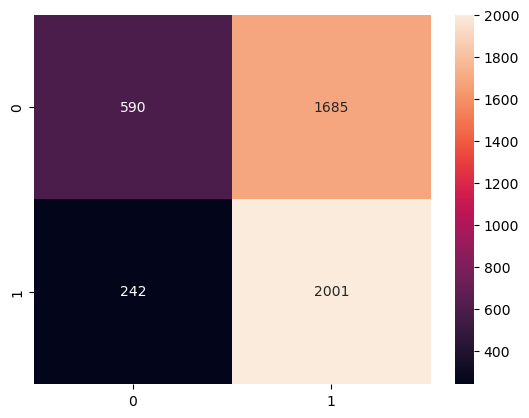

In [66]:
#Heat map for confusion matrix
confusion_matrix_gb_rus = confusion_matrix(y_test_rus,y_predict_gb_rus)
sns.heatmap(confusion_matrix_gb_rus,annot=True,fmt='g')

<function matplotlib.pyplot.show(close=None, block=None)>

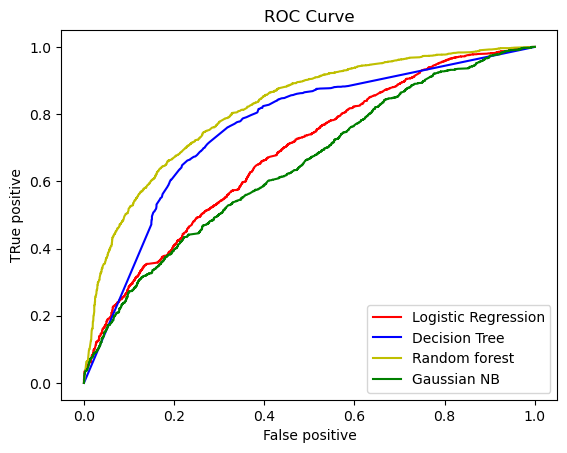

In [67]:
#Plotting ROC curve of classification algorithm 
from sklearn.metrics import roc_curve
fpr_lr_rus,tpr_lr_rus,threshold_rus = roc_curve(y_test_rus,lr_clf_rus.predict_proba(X_test_rus)[:, 1])
fpr_dt_rus,tpr_dt_rus,threshold_rus = roc_curve(y_test_rus,dt_clf_rus.predict_proba(X_test_rus)[:, 1])
fpr_rf_rus,tpr_rf_rus,threshold_rus = roc_curve(y_test_rus,rf_clf_rus.predict_proba(X_test_rus)[:, 1])
fpr_gb_rus,tpr_gb_rus,threshold_rus = roc_curve(y_test_rus,gb_clf_rus.predict_proba(X_test_rus)[:, 1])
plt.title("ROC Curve")
plt.plot(fpr_lr_rus,tpr_lr_rus,'r',label = 'Logistic Regression')
plt.plot(fpr_dt_rus,tpr_dt_rus,'b',label = 'Decision Tree')
plt.plot(fpr_rf_rus,tpr_rf_rus,'y',label = 'Random forest')  
plt.plot(fpr_gb_rus,tpr_gb_rus,'g',label = 'Gaussian NB')
plt.ylabel("TRue positive")
plt.xlabel("False positive")
plt.legend()
plt.show